# Dataset Distributions

This notebook investigates the distributions of key political identity-building categories related to political actors, based on dataset metadata - with a focus on sentiment-related trends of membership and group relation categories.  

### Categories of Interest
- **Membership**: Political parties, parliamentary groups, ministers  
- *Ideology*: Party families, GAL–TAN positionings (CHES variables)  
- **Group Relations**: Party status (Coalition vs. Opposition), political orientation (LREGEN, LRECON, Wikipedia classifications)  

### Purpose

The goal of this exploration is to:
1. *Investigate basic distributions* to gain an overview of the dataset’s structure  
2. *Identify trends* within the political landscape of the studied parliamentary period  

### Focus Areas
- *Party activity*: How political parties and groups are distributed and represented  
- *Sentiment trends*: Patterns in sentiment across different ideological or group categories  

--- 

Sample input: 
Pre-processed dataset [ParlaMint-SI_5.1_master.tsv](../Sample/Datasets/ParlaMint-SI_5.1_master.tsv) 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [2]:
#df = pd.read_csv("../Sample/Datasets/Sample_master.tsv", sep="\t", encoding="utf-8") #Sample input
df =  pd.read_csv("../ParlaMint-SI_full_dataset.tsv", sep="\t", encoding="utf-8") #Full dataset input
df.head()

,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Senti_n,Sents,Words,Tokens,Parties,Year,party_id,lrgen,galtan,Seat
0,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u1,Spoštovane kolegice poslanke in kolegi poslanc...,2013-03-27,Term 6,Redna,Reference,Chairperson,MP,notMinister,SD,...,3.25,56,986,1149,ZLSD/SD,2013,NaN,NaN,NaN,NaN
1,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u2,Hvala lepa za besedo. Spoštovana predsednica V...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.33,19,284,327,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
2,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u3,Hvala tudi vam. Dajem besedo predsednici Vlade...,2013-03-27,Term 6,Redna,Reference,Chairperson,MP,notMinister,SD,...,3.00,3,11,15,ZLSD/SD,2013,NaN,NaN,NaN,NaN
3,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u4,"Spoštovane poslanke in poslanci, lep pozdrav p...",2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,3.51,29,562,662,-,2013,NaN,NaN,NaN,NaN
4,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u5,Hvala za odgovor. Gospod Prevc bo predstavil z...,2013-03-27,Term 6,Redna,Reference,Chairperson,MP,notMinister,SD,...,3.00,3,12,15,ZLSD/SD,2013,NaN,NaN,NaN,NaN


## Dataset characteristics

In [3]:
print(df.shape)
df.describe(include="all")

(311354, 30)


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Senti_n,Sents,Words,Tokens,Parties,Year,party_id,lrgen,galtan,Seat
count,311354,311354,311354,311354,311354,311354,311354,311354,311354,311354,...,311347.000000,311354.000000,311354.000000,311354.000000,311354,311354.000000,68490.000000,68490.000000,68490.000000,68490.000000
unique,311354,275764,1520,6,2,3,2,2,2,26,...,NaN,NaN,NaN,NaN,20,NaN,NaN,NaN,NaN,NaN
top,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u1,"Hvala lepa. Gospod minister, izvolite.",2007-11-28,Term 4,Redna,Reference,Chairperson,MP,notMinister,SDS,...,NaN,NaN,NaN,NaN,SDS,NaN,NaN,NaN,NaN,NaN
freq,1,584,1434,63441,234910,277315,157584,290736,295706,63347,...,NaN,NaN,NaN,NaN,63347,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.127889,12.449440,224.573807,262.348918,NaN,2010.867845,2904.653395,5.043709,4.990492,17.822409
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.289614,18.460735,368.804434,429.996543,NaN,6.086519,3.652408,1.944034,2.308455,11.715680
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,2000.000000,2901.000000,0.700000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.750000,2.000000,12.000000,15.000000,NaN,2006.000000,2902.000000,3.600000,2.800000,7.800000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.840000,5.000000,62.000000,75.000000,NaN,2010.000000,2903.000000,4.200000,4.500000,12.200000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,16.000000,319.000000,371.000000,NaN,2016.000000,2906.000000,6.900000,7.400000,31.100000


In [4]:
reg_speeches = df[df["Speaker_role"] == "Regular"]
party = df["Speaker_party"].unique()

print("No. of all speeches: ", len(df))
print("Speeches of regular speakers: ", len(reg_speeches), "%: ", (len(reg_speeches)/len(df))*100)
print("Earliest date: ", df["Date"].min())
print("Latest date: ", df["Date"].max())
print("No. of unique parties ", len(party), party)
print("Sentiment 6-class: ", df["Senti_6"].value_counts())
print("Sentiment 3-class: ", df["Senti_3"].value_counts()
)

reg_6 = reg_speeches["Senti_6"].value_counts()
reg_3 = reg_speeches["Senti_3"].value_counts()
percent_reg6 = (reg_6 / len(reg_speeches)) * 100
percent_reg3 = (reg_3 / len(reg_speeches)) * 100
print ("Distribution of the 6-class sent in procedural speeches: ", percent_reg6)
print("Distribution of the 3-class sent in procedural speeches: ", percent_reg3)


No. of all speeches:  311354
Speeches of regular speakers:  153770 %:  49.38751389094086
Earliest date:  2000-10-27
Latest date:  2022-04-06
No. of unique parties  26 ['SD' 'SLS' '-' 'NSi' 'PS' 'SDS' 'DL' 'DeSUS' 'NeP' 'IMNS' 'SMC' 'ZL'
 'ZaAB' 'NP' 'Levica' 'LMŠ' 'SAB' 'SNS' 'Konkretno' 'DLGV' 'Lipa' 'Zares'
 'LDS' 'ZLSD' 'SLS+SKD' 'SMS']
Sentiment 6-class:  Senti_6
neutral positive    155668
negative             66231
neutral negative     36444
mixed negative       32109
mixed positive       15934
positive              4961
-                        7
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Neutral     192112
Negative     98340
Positive     20895
-                7
Name: count, dtype: int64
Distribution of the 6-class sent in procedural speeches:  Senti_6
negative            42.144111
mixed negative      17.853938
neutral negative    14.145152
neutral positive    13.047408
mixed positive       9.593549
positive             3.211290
-                    0.004552
Name: cou

In [5]:
#Sentiment in procedural speeches
chair = df[df["Speaker_role"] != "Regular"]
print("Sentiment 6-class: ", chair["Senti_6"].value_counts())
print("Sentiment 3-class: ", chair["Senti_3"].value_counts()
)

chair_6 = chair["Senti_6"].value_counts()
chair_3 = chair["Senti_3"].value_counts()

percent_chair6 = (chair_6 / len(chair)) * 100
percent_chair3 = (chair_3 / len(chair)) * 100

print ("Distribution of the 6-class sent in procedural speeches: ", percent_chair6)
print("Distribution of the 3-class sent in procedural speeches: ", percent_chair3)

Sentiment 6-class:  Senti_6
neutral positive    135605
neutral negative     14693
mixed negative        4655
negative              1426
mixed positive        1182
positive                23
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Neutral     150298
Negative      6081
Positive      1205
Name: count, dtype: int64
Distribution of the 6-class sent in procedural speeches:  Senti_6
neutral positive    86.052518
neutral negative     9.323916
mixed negative       2.953980
negative             0.904914
mixed positive       0.750076
positive             0.014595
Name: count, dtype: float64
Distribution of the 3-class sent in procedural speeches:  Senti_3
Neutral     95.376434
Negative     3.858894
Positive     0.764672
Name: count, dtype: float64


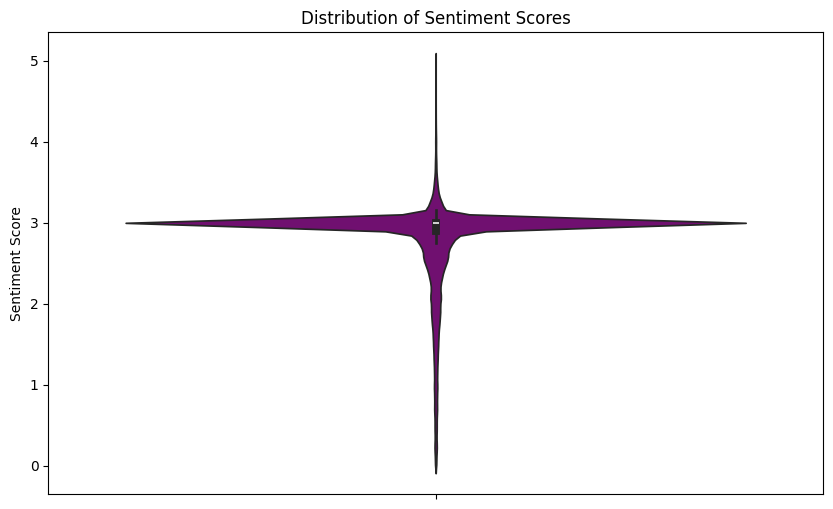

In [6]:
#Sentiment scores distribution
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=chair,
    y="Senti_n", 
    color="purple",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.show()

Observations (sample run): 

Entire dataset:
- No. of all speeches:  5404
- Speeches of regular speakers:  2674 %:  49.48186528497409
- Sentiment 3-class:  Senti_3
    - Negative    61.443530
    - Neutral     25.654450
    - Positive    12.902019

Chairperson speeches only: 
Distribution of the 3-class sent in procedural speeches:  Senti_3:
    - Neutral     97.472527
    - Negative     2.124542
    - Positive     0.402930


- The dataset consists of over 50% of chairperson speeches, which heavily dominates in the Neutral sentiment, which can directly impact the analysis results. Therefore, for the majority of the analysis, these speeches should be removed.

In [7]:
# Removing procedural speeches for the analysis, rechecking base characteristics
df = df[df["Speaker_role"] == "Regular"]
df = df[df["Senti_3"] != "-"]

print("No. of all speeches: ", len(df))
print("Earliest date: ", df["Date"].min())
print("Latest date: ", df["Date"].max())
print("No. of unique parties ", len(party), party)
print("Sentiment 6-class: ", df["Senti_6"].value_counts())
print("Sentiment 3-class: ", df["Senti_3"].value_counts())


No. of all speeches:  153763
Earliest date:  2000-10-27
Latest date:  2022-04-06
No. of unique parties  26 ['SD' 'SLS' '-' 'NSi' 'PS' 'SDS' 'DL' 'DeSUS' 'NeP' 'IMNS' 'SMC' 'ZL'
 'ZaAB' 'NP' 'Levica' 'LMŠ' 'SAB' 'SNS' 'Konkretno' 'DLGV' 'Lipa' 'Zares'
 'LDS' 'ZLSD' 'SLS+SKD' 'SMS']
Sentiment 6-class:  Senti_6
negative            64805
mixed negative      27454
neutral negative    21751
neutral positive    20063
mixed positive      14752
positive             4938
Name: count, dtype: int64
Sentiment 3-class:  Senti_3
Negative    92259
Neutral     41814
Positive    19690
Name: count, dtype: int64


## Party-level Overview
Inspecting speech and sentiment distributions across party-, status- and political orientation.

In [8]:
# Table with overview of speeches, sentiment avg and sent percentages
#mapping = {"Far right":"FR", 
# "Right to far right": "R-FR", 
# "Centre-right":"CR", 
# "Centre to centre-left":"C-CR", 
# "Centre":"C", 
# "Centre to centre-left":"C-CL", 
# "Centre-left":"CL", 
# "Left":"L", 
# "Left to far left": "L-FL", 
# "Far left": "FL", 
# "-":"-", }

status = df.groupby(['Parties','Party_status']).size().unstack(fill_value=0)
status.columns = ['Speech (U)', 'Speech (C)', 'Speech (O)']
avg_sent = df.groupby(['Parties', 'Party_status'])["Senti_n"].mean().unstack(fill_value=0)
avg_sent.columns = ['Avg. Sent (U)', 'Avg. Sent (C)', 'Avg. Sent (O)']
sent_count = df.groupby(['Parties', df['Senti_3']]).size().unstack(fill_value=0)
sent_percent = sent_count.div(sent_count.sum(axis=1), axis=0) * 100

party_metadata = df[['Parties', 'Party_orientation']].drop_duplicates().set_index('Parties')


overview = (
    status.merge(avg_sent, on="Parties", how="left")
    .merge(sent_percent, on="Parties", how="left")
    .merge(party_metadata, on="Parties", how='left')
    .reset_index()
    )

overview.rename(columns={
    'Positive': '% Positive',
    'Neutral': '% Neutral',
    'Negative': '% Negative'
}, inplace=True)


overview['Total Speeches'] = overview['Speech (U)'] + overview['Speech (C)'] + overview['Speech (O)']
total_speeches = overview['Total Speeches'].sum()
overview['Speech %'] = (overview['Total Speeches'] / total_speeches) * 100
overview = overview[['Parties', 'Party_orientation', 'Total Speeches', 'Speech %', 'Speech (C)', 'Speech (O)','Speech (U)',
               'Avg. Sent (C)', 'Avg. Sent (O)','Avg. Sent (U)', '% Positive', '% Neutral', '% Negative']]

cols_to_format = [
    'Speech %', 'Avg. Sent (C)', 'Avg. Sent (O)', 'Avg. Sent (U)',
    '% Positive', '% Neutral', '% Negative'
]

for col in cols_to_format:
    overview[col] = overview[col].map(lambda x: f"{x:.1f}")

overview

,Parties,Party_orientation,Total Speeches,Speech %,Speech (C),Speech (O),Speech (U),Avg. Sent (C),Avg. Sent (O),Avg. Sent (U),% Positive,% Neutral,% Negative
0,-,-,17954,11.1,0,0,17954,0.0,0.0,2.2,18.4,50.3,31.3
1,DLGV/DL,Centre to centre-right,1146,0.7,1070,52,24,1.9,2.1,2.4,22.5,27.7,49.8
2,DLGV/DL,Right,1146,0.7,1070,52,24,1.9,2.1,2.4,22.5,27.7,49.8
3,DeSUS,Centre to centre-left,6792,4.2,6611,181,0,2.1,2.6,0.0,27.7,28.4,43.9
4,IMNS,-,1036,0.6,0,0,1036,0.0,0.0,2.0,22.7,34.2,43.1
5,LDS,Centre to centre-left,14100,8.8,7674,6426,0,1.7,0.9,0.0,10.3,27.3,62.3
6,LMŠ,Centre to centre-left,2810,1.7,557,2213,40,1.8,0.8,2.2,8.4,18.5,73.1
7,Lipa,-,395,0.2,0,0,395,0.0,0.0,0.8,4.1,19.0,77.0
8,NP,-,1688,1.0,0,0,1688,0.0,0.0,1.1,11.9,16.2,71.9
9,NSi,Centre-right,13358,8.3,4805,8523,30,2.1,1.1,2.0,13.9,26.9,59.2


## Party Activity
Investigation of party presence throughout the period, covered by the dataset. There are also several exceptions that need to be handled: 
- NeP = parliamentary group of independent MPs, which could be considered for the analysis, however, since there is no destinction between different NePs in different mandates, this is not included in the visualisation.
- NP = individual independent MPs, not connected into a parliamentary group. In addition to them not being a formal parliamentary entity but individual speakers, they have similar problem as NeP, ruled out
- Lipa and Konkretno = both are non-parliamentary parties. Specfically, both parties were consistuted within Parliament after being elected as a different parliamentary party. Included in the analysis

In [9]:
df["Month"] = df["Date"].str.split("-").str[:2].str.join("-")

df_notMinister = df[df["Speaker_minister"]=="notMinister"] #Remove minister speaker, only interested into MP activity
activity = df_notMinister.groupby(['Term', 'Speaker_party']).agg( #Can also be checked by aggregated parties - "Parties"
    Start_date=('Date', 'min'),
    End_date=('Date', 'max'),
    Speech_count=('Date', 'size'),
    Avg_sentiment=('Senti_n','mean')

).reset_index()
activity = activity[~activity['Speaker_party'].isin(["-", "NeP", "NP"])]
activity["Speaker_party"].sort_values(ascending=True)


activity

,Term,Speaker_party,Start_date,End_date,Speech_count,Avg_sentiment
1,Term 3,DeSUS,2000-10-27,2004-10-07,666,2.168994
2,Term 3,IMNS,2000-11-16,2004-08-31,301,1.496811
3,Term 3,LDS,2000-10-27,2004-10-07,5355,1.542486
4,Term 3,NSi,2000-11-30,2004-10-07,4367,1.100183
6,Term 3,SDS,2000-11-30,2004-10-07,5327,0.944992
7,Term 3,SLS,2002-03-19,2004-10-07,1719,1.568104
8,Term 3,SLS+SKD,2000-10-27,2002-03-01,809,1.605266
9,Term 3,SMS,2000-11-16,2004-09-01,705,1.672454
10,Term 3,SNS,2000-10-27,2004-10-07,1935,1.201147
11,Term 3,ZLSD,2000-11-10,2004-10-07,1886,1.965361


In [10]:
import plotly.express as px
from PIL import Image

def plot_party_activity(df, mode="sentiment"):
    if mode=="activity":  ## Use for sample visualisation, for full dataset, use timeline
        fig = px.timeline(
            activity, 
            x_start="Start_date", 
            x_end="End_date",
            y="Speaker_party", #Can be either Speaker_party for full range of individual parties, or Grouped_parties to emphasise changes in the lifespan of parties 
            color="Speech_count", 
            title="Party activity Across Terms (Speech count)", 
            labels={"Speech_count": "Speech Count"},
            color_continuous_scale="viridis"
        )
    elif mode=="sentiment":
        fig = px.timeline(
            activity,
            x_start="Start_date",
            x_end="End_date",
            y="Speaker_party",
            color="Avg_sentiment",
            title="Party Activity Across Terms (Average sentiment)",
            labels={"Avg_sentiment": "Sentiment (mean)"},
        )
    else:
        raise ValueError("mode must be one of: activity, sentiment")
    fig.update_layout(
        height=600,  
        width=950,
        yaxis_title="Parties",
        xaxis_title="")
    return fig

#fig.write_image("path.png")


fig = plot_party_activity(activity, mode="activity")
fig.show()

## Sentiment trends (across party, political orientations, statuses...)

In [11]:
sent_mapping = {
    "negative":"Negative", 
    "neutral negative":"Neutral Negative", 
    "neutral positive":"Neutral Positive", 
    "mixed negative":"Mixed Negative", 
    "mixed positive":"Mixed Positive", 
    "positive":"Positive",
}

df['Senti_6'] = df["Senti_6"].map(sent_mapping).fillna(df["Senti_6"])
df["Senti_6"].unique()

array(['Negative', 'Mixed Positive', 'Neutral Positive', 'Mixed Negative',
       'Neutral Negative', 'Positive'], dtype=object)

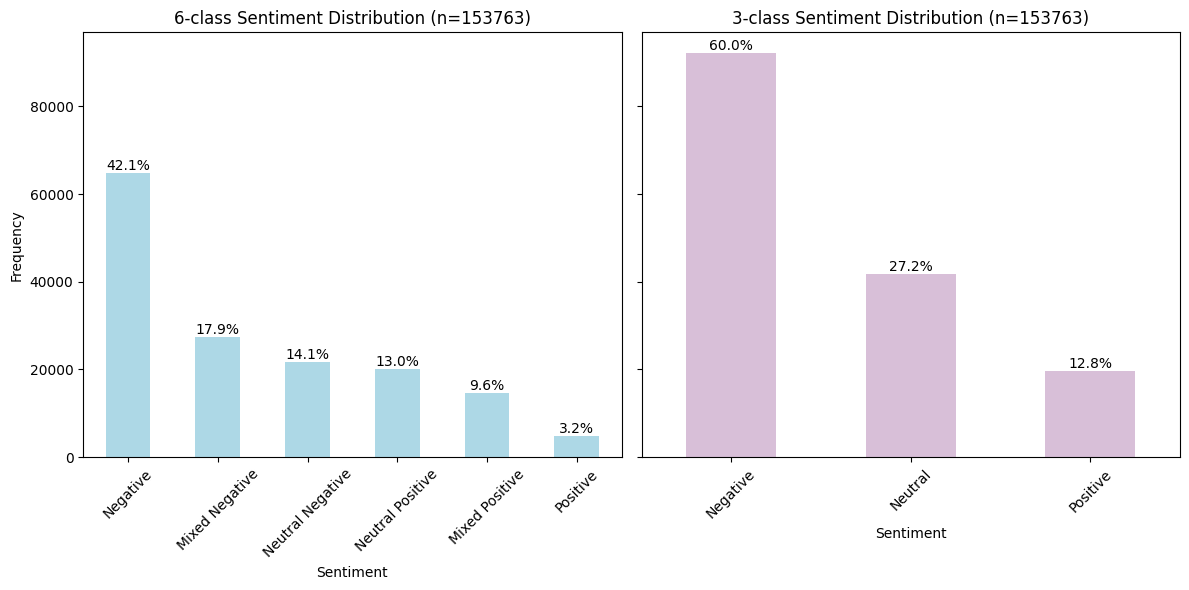

In [12]:
#General sentiment distribution in the corpus
df_sent6 = df["Senti_6"].value_counts()
df_sent3 = df["Senti_3"].value_counts()

def add_percentage(ax, counts):
    total = counts.sum()
    for p in ax.patches:
        percentage = f"{(p.get_height() / total) * 100:.1f}%"
        ax.annotate(percentage,  (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
df_sent6.plot(kind='bar', ax=axes[0], color = 'lightblue')
axes[0].set_title(f'6-class Sentiment Distribution (n={len(df)})')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
add_percentage(axes[0], df_sent6)

df_sent3.plot(kind='bar', ax=axes[1], color='thistle')
axes[1].set_title(f'3-class Sentiment Distribution (n={len(df)})')
axes[1].set_xlabel('Sentiment')
axes[1].tick_params(axis='x', rotation=45)
add_percentage(axes[1], df_sent3)

plt.tight_layout()
plt.show()

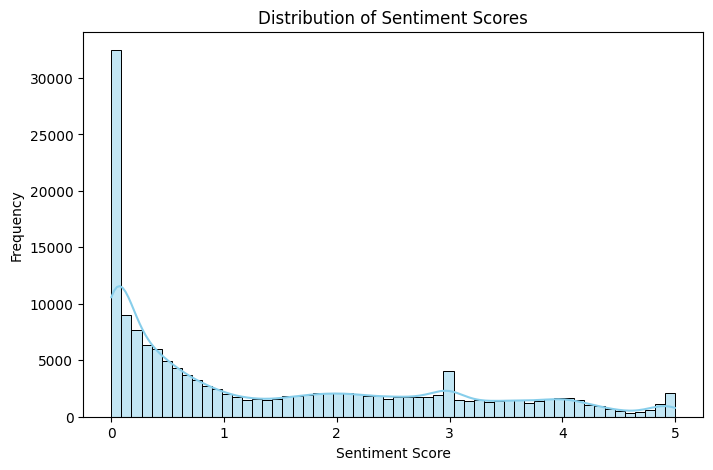

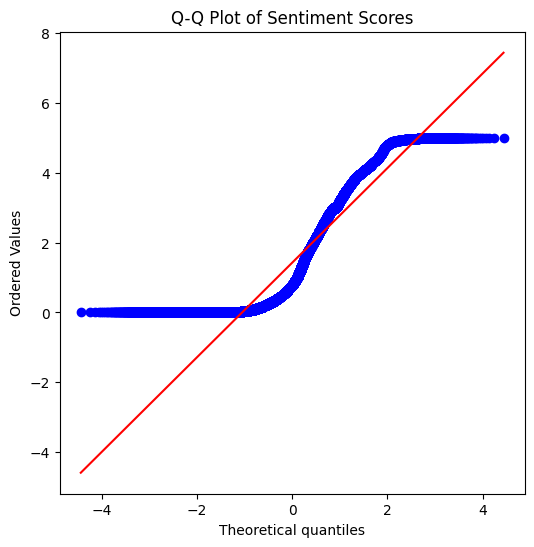

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Senti_n"], kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(df["Senti_n"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Sentiment Scores")
plt.show()

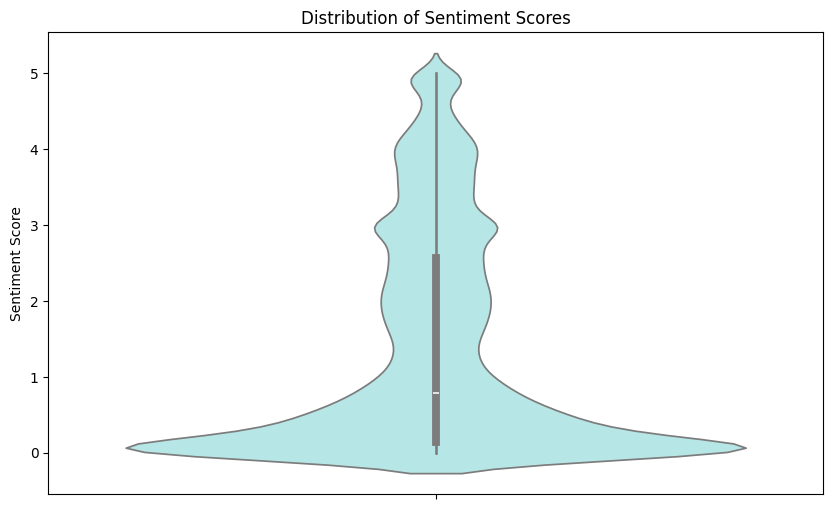

In [14]:
#Sentiment scores distribution
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    y="Senti_n", 
    color="paleturquoise",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.show()


### Party status x Sentiment (categories, numerical scores)

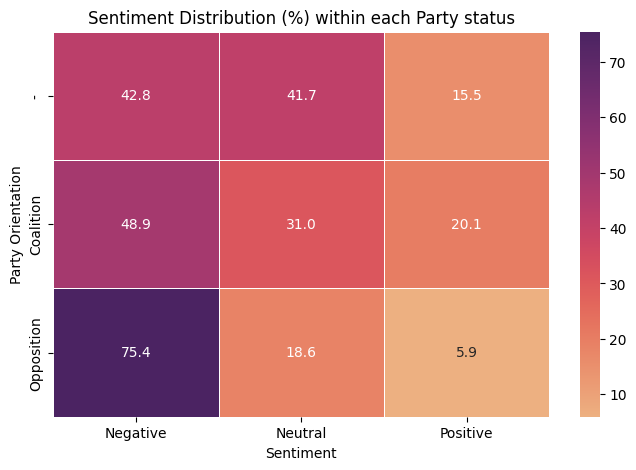

In [15]:
# Party status x Sentiment categories 
# Choose normalization mode: "row", "col", "global", or "none"

mode = "row"
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Party_status'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Party_status'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party status"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Status Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party Status"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party Orientation")
plt.xlabel("Sentiment")
plt.show()



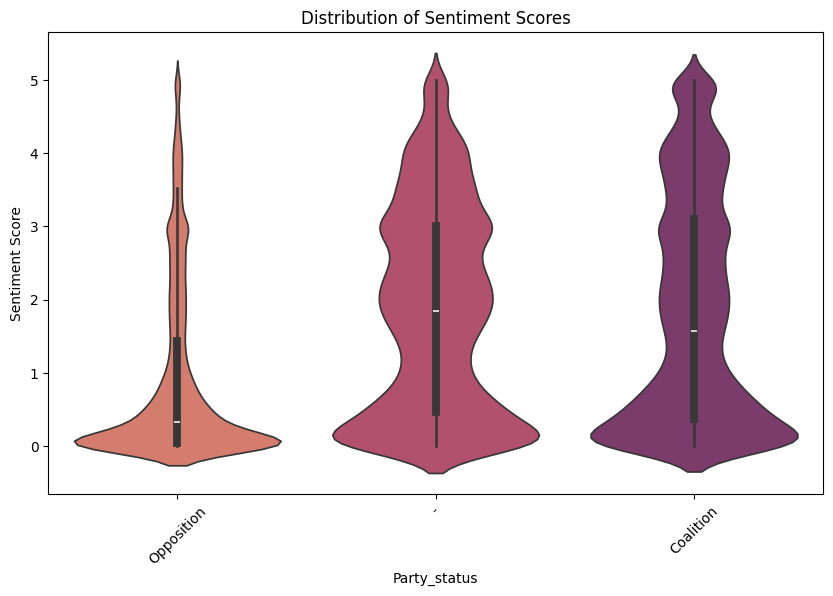

In [16]:
#Party status x sentiment score distribution

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Party_status",
    y="Senti_n", 
    hue="Party_status",
    palette="flare",
)
plt.title("Distribution of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.xlabel("Party_status")
plt.xticks(rotation=45)
plt.show()

In [17]:
#Party status x average sentiment score (across years)
# Plot sample trends per "Month", use "Year" for better full dataset visualisations

status_term = df.groupby(["Party_status", "Year"]).agg({"Senti_n":"mean"}).reset_index()
status_term

fig=px.line(status_term, x="Year", y="Senti_n", color="Party_status", markers=True, 
            color_discrete_sequence=px.colors.qualitative.Vivid)
fig.update_layout(
    height=500,  
    width=950,
    yaxis=dict(range=[0, 5]),

    yaxis_title='Avg. Sentiment score',
    legend_title='Party',
    template='plotly_white'
)
fig.show()

### Political orientation x Sentiment (categories, scores)

In [18]:
# Political orientation x Sentiment categories 
mode = "row"
senti_version = 6

order = ["-", "Left", "Centre-left", "Centre to centre-left", "Centre", "Centre to centre-right", "Centre-right", "Right", "Right to far-right"]

if senti_version == 3:
    crosstab = pd.crosstab(df['Party_orientation'], df['Senti_3'])
elif senti_version == 6:
    crosstab = pd.crosstab(df['Party_orientation'], df['Senti_6'])
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party Orientation category"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Orientation Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party Orientation"


plt.figure(figsize=(8, 5))
data 



Senti_6,Mixed Negative,Mixed Positive,Negative,Neutral Negative,Neutral Positive,Positive
Party_orientation,,,,,,
-,16.551724,14.213291,20.954556,23.900434,21.173784,3.206211
Centre,6.086957,29.565217,18.260870,10.434783,18.260870,17.391304
Centre to centre-left,18.043294,11.697303,38.511307,14.318539,12.942919,4.486637
Centre to centre-right,21.501390,16.218721,28.544949,13.438369,15.013902,5.282669
Centre-left,19.974652,10.062217,40.256548,14.060220,12.278209,3.368154
Centre-right,18.751169,11.356408,37.549111,13.751169,13.942937,4.649205
Left,15.823659,1.990050,69.928137,6.771697,5.140962,0.345495
Right,16.896867,5.693168,54.748587,10.561612,10.219166,1.880600
Right to far-right,17.046317,4.745634,55.618831,10.541635,10.528980,1.518603


<Figure size 800x500 with 0 Axes>

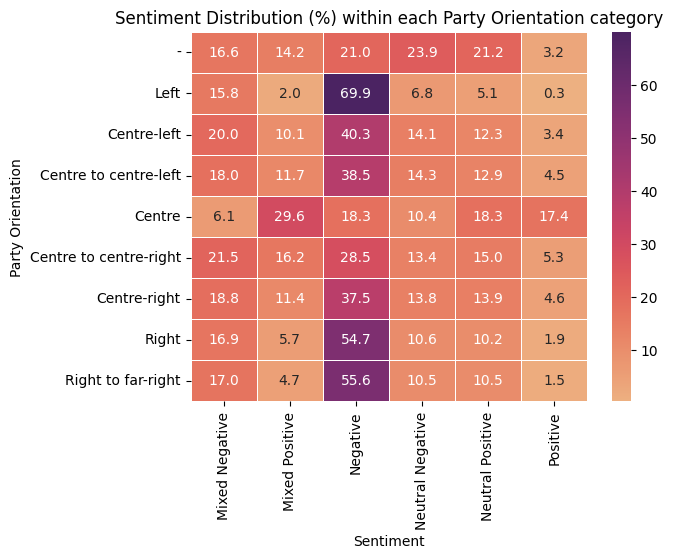

In [19]:
data = data.reindex(order)
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party Orientation")
plt.xlabel("Sentiment")
plt.show()

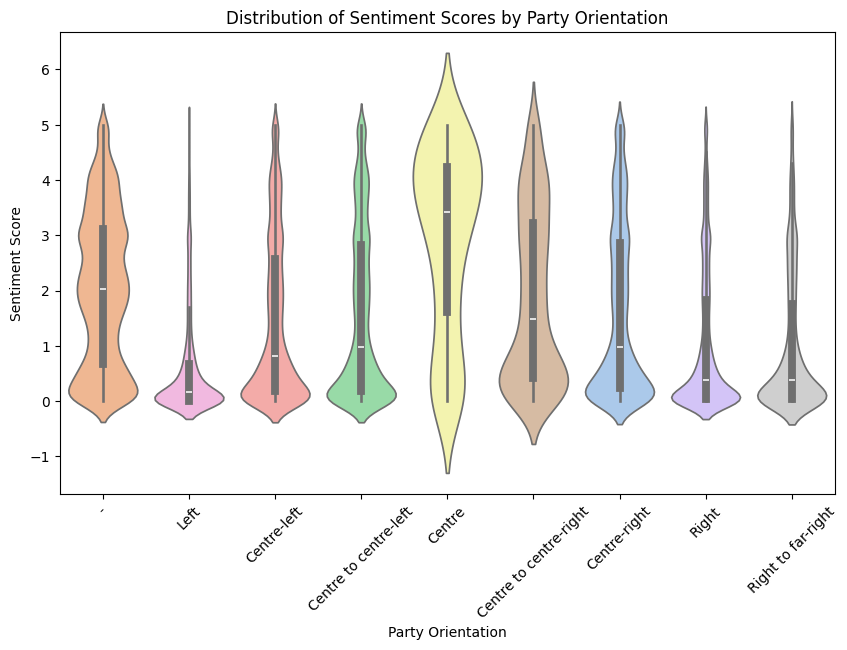

In [20]:
#Political orientation x sentiment scores (distributions)
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Party_orientation", 
    y="Senti_n", 
    hue="Party_orientation", 
    palette="pastel",
    order=order,
)
plt.title("Distribution of Sentiment Scores by Party Orientation")
plt.xlabel("Party Orientation")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45)
plt.show()


In [21]:
#Political orientation x Sentiment scores (across years)
# Plot sample trends per "Month", use "Year" for better full dataset visualisations


status_term = df.groupby(["Party_orientation", "Year"]).agg({"Senti_n":"mean"}).reset_index()
status_term

fig=px.line(status_term, x="Year", y="Senti_n", color="Party_orientation", category_orders={"Party_orientation":["-", "Left", "Centre-left", "Centre to centre-left", "Centre", "Centre to centre-right", "Centre-right", "Right", "Right to far-right"]}, markers=True, 
            color_discrete_sequence=px.colors.qualitative.Vivid)
fig.update_layout(
    height=500,  
    width=950,
    yaxis=dict(range=[0, 5]),

    yaxis_title='Avg. Sentiment score',
    legend_title='Orientation',
    template='plotly_white',
)


fig.show()

### Parliamentary groups/Political parties x Sentiment

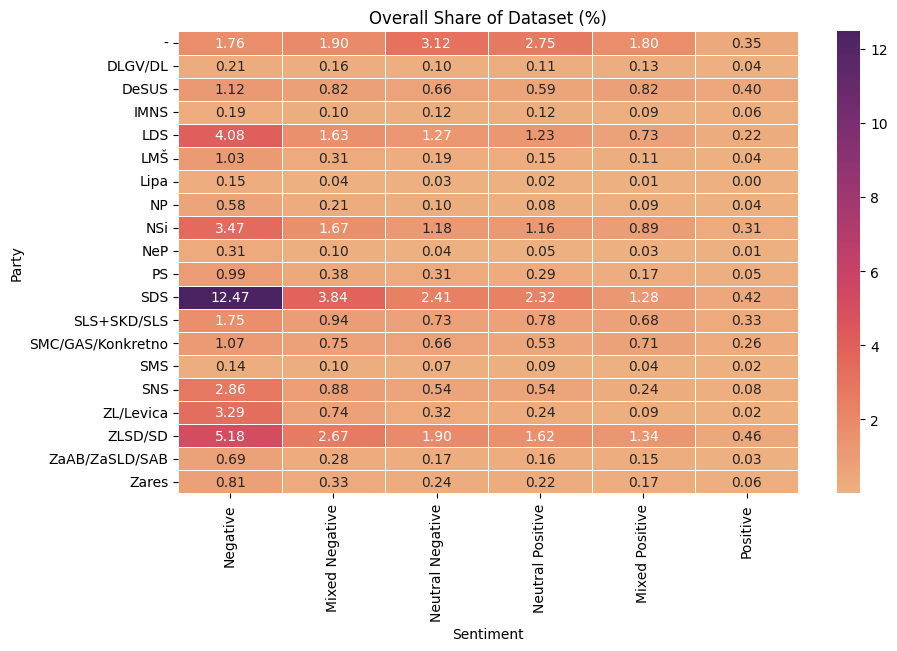

In [22]:
# Political party x Sentiment categories 
mode = "global"
senti_version = 6

sent6_order = ["Negative", "Mixed Negative", "Neutral Negative", "Neutral Positive", "Mixed Positive", "Positive"]
sent3_order = ["Negative", "Neutral", "Positive"]

if senti_version == 3:
    crosstab = pd.crosstab(df['Parties'], df['Senti_3'])
    crosstab = crosstab.reindex(columns=sent3_order)

elif senti_version == 6:
    crosstab = pd.crosstab(df['Parties'], df['Senti_6'])
    crosstab = crosstab.reindex(columns=sent6_order)
else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within each Party"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Party Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Party"

plt.figure(figsize=(10, 6))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Party")
plt.xlabel("Sentiment")
plt.show()


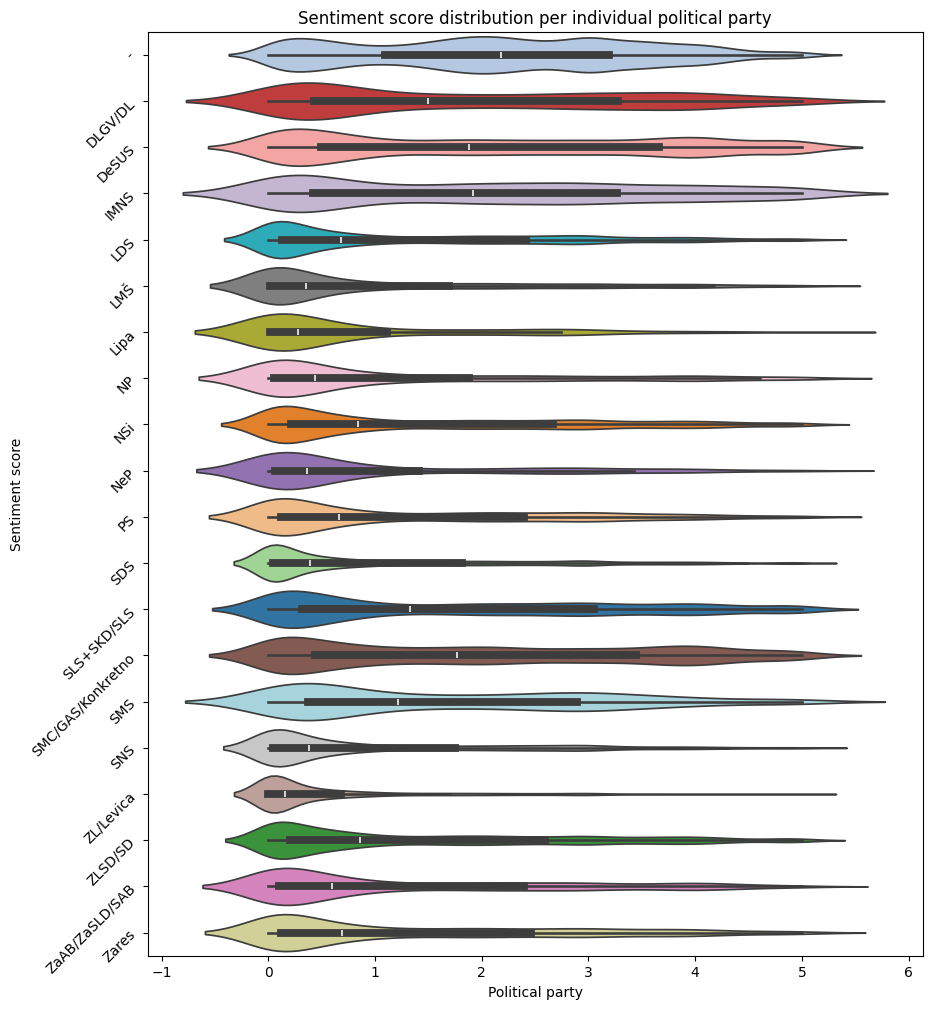

In [23]:
#Parliamentary groups x Sentiment score distributions
party_order = sorted(df["Parties"].unique())
plt.figure(figsize=(10, 12))
sns.violinplot(
    data=df,
    x="Senti_n", 
    y="Parties",
    hue="Parties",
    palette="tab20",
    order=party_order
)

plt.title("Sentiment score distribution per individual political party")
plt.xlabel("Political party"), 
plt.ylabel("Sentiment score"), 
plt.yticks(rotation=45), 
plt.show()

In [24]:

party_sent = df.groupby(["Term", "Year", "Parties"])["Senti_n"].mean().reset_index()
party_sent = party_sent.sort_values(by="Term")
party_sent["Senti_n"] = pd.to_numeric(party_sent["Senti_n"])
party_sent.head(10)



,Term,Year,Parties,Senti_n
0,Term 3,2000,-,2.710400
28,Term 3,2002,SMS,1.677637
29,Term 3,2002,SNS,1.184581
30,Term 3,2002,ZLSD/SD,1.966221
31,Term 3,2003,-,2.177101
32,Term 3,2003,DeSUS,2.119293
33,Term 3,2003,IMNS,1.078261
34,Term 3,2003,LDS,1.716471
35,Term 3,2003,NSi,1.051535
36,Term 3,2003,SDS,0.868899


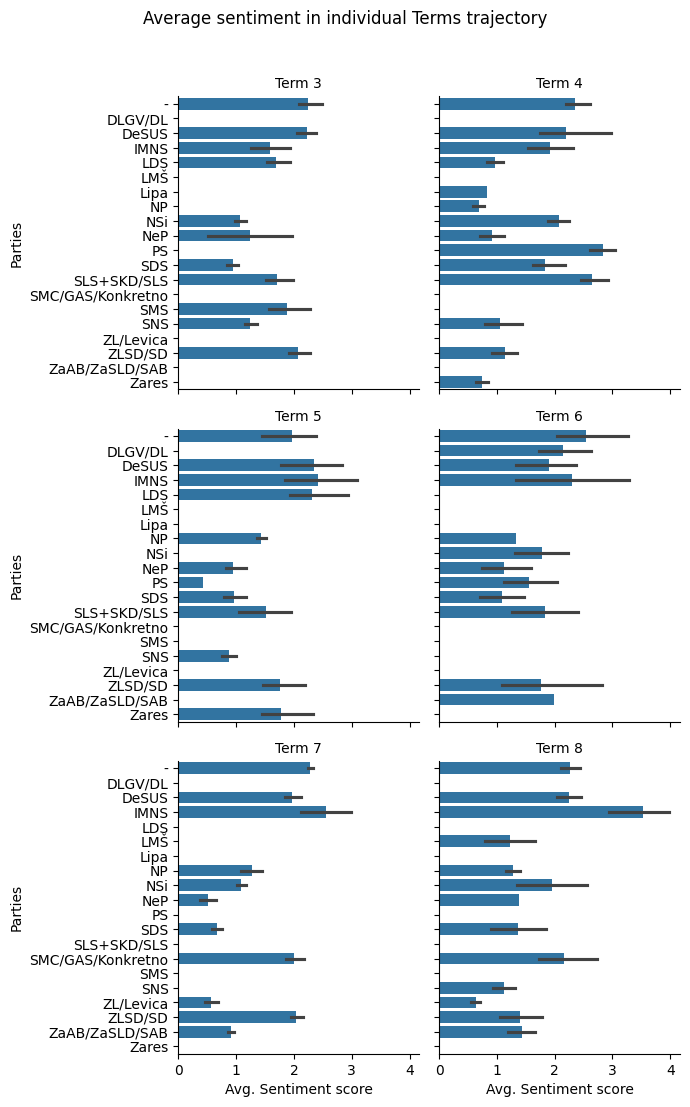

In [25]:
party_order = sorted(party_sent["Parties"].unique())

g = sns.FacetGrid(party_sent, col="Term" , col_wrap=2, height=3.5) 
g.map_dataframe(sns.barplot, x="Senti_n", y="Parties", order=party_order) 
g.set_axis_labels("Avg. Sentiment score", "Parties") 
g.set_titles("{col_name}"),
g.legend
g.figure.suptitle("Average sentiment in individual Terms trajectory", y=1.05)
plt.show()

### Ministers distributions

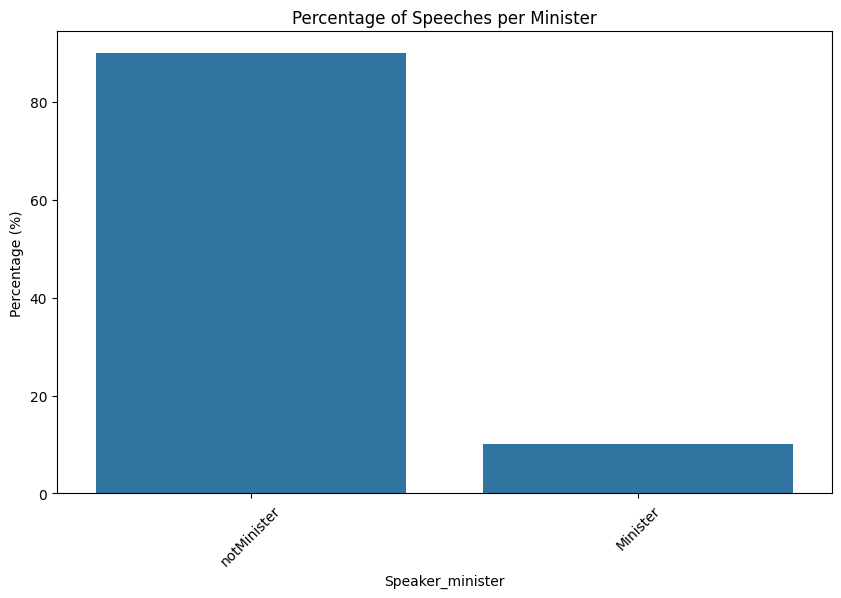

In [27]:
counts = df['Speaker_minister'].value_counts()
percentages = counts / counts.sum() * 100
plot_df = percentages.reset_index()
plot_df.columns = ['Speaker_minister', 'Percentage']

plt.figure(figsize=(10,6))
sns.barplot(data=plot_df, x='Speaker_minister', y='Percentage')
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.title("Percentage of Speeches per Minister")
plt.show()

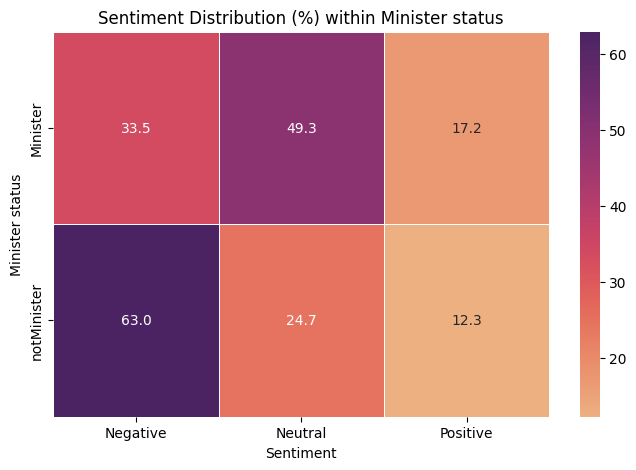

In [28]:
# Minister status x Sentiment categories 
mode = "row"
senti_version = 3

if senti_version == 3:
    crosstab = pd.crosstab(df['Speaker_minister'], df['Senti_3'])
    crosstab = crosstab.reindex(columns=sent3_order)
elif senti_version == 6:
    crosstab = pd.crosstab(df['Speaker_minister'], df['Senti_6'])
    crosstab = crosstab.reindex(columns=sent6_order)

else:
    raise ValueError("Senti_version must be either 3 or 6")

if mode == "row":
    # Each row sums to 100%
    data = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
    fmt = ".1f"
    title = "Sentiment Distribution (%) within Minister status"

elif mode == "col":
    # Each column sums to 100%
    data = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
    fmt = ".1f"
    title = "Minister status Contributions (%) within each Sentiment"

elif mode == "global":
    # Whole table sums to 100%
    data = crosstab / crosstab.values.sum() * 100
    fmt = ".2f"
    title = "Overall Share of Dataset (%)"

else:  # raw counts
    data = crosstab
    fmt = "g"
    title = "Raw Sentiment Counts by Minister status"


plt.figure(figsize=(8, 5))
sns.heatmap(data, cmap="flare", annot=True, linewidth=.5, fmt=fmt)
plt.title(title)
plt.ylabel("Minister status")
plt.xlabel("Sentiment")
plt.show()

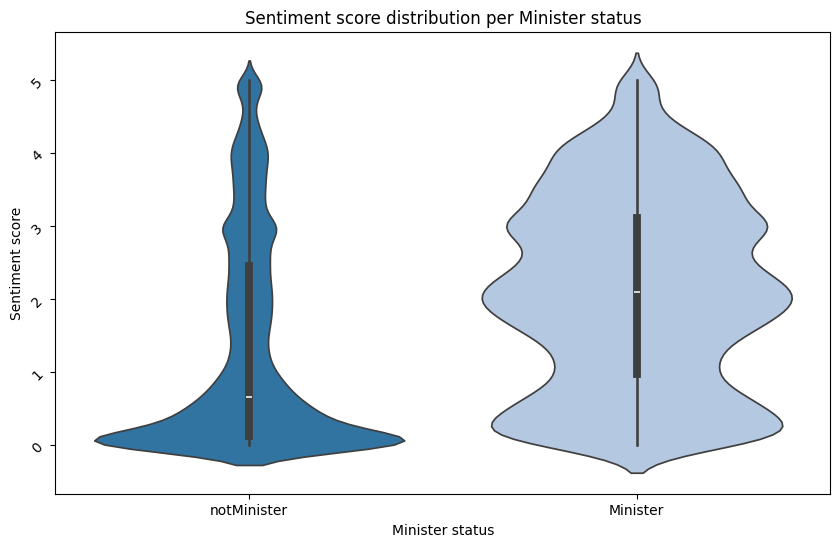

In [29]:
#Minister status x Sentiment score distributions
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Speaker_minister", 
    y="Senti_n",
    hue="Speaker_minister",
    palette="tab20"
)

plt.title("Sentiment score distribution per Minister status")
plt.xlabel("Minister status"), 
plt.ylabel("Sentiment score"), 
plt.yticks(rotation=45), 
plt.show()